# Setup

In [78]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error


In [63]:
# Set the index when we import the data
df = pd.read_csv("airmiles.csv", index_col = "Date", parse_dates=True, dayfirst=True)
df.head()

,airmiles
Date,
1996-01-01,30983174
1996-02-01,32147663
1996-03-01,38342975
1996-04-01,35969113
1996-05-01,36474391


In [64]:
# Change the name of the time series variable t y
df = df.rename(columns = {"airmiles": "y"})
df.head(12)

,y
Date,
1996-01-01,30983174
1996-02-01,32147663
1996-03-01,38342975
1996-04-01,35969113
1996-05-01,36474391
1996-06-01,38772238
1996-07-01,40395657
1996-08-01,41738499
1996-09-01,33580773


In [65]:
# Change the frequency
df = df.asfreq('MS')
df.index

DatetimeIndex(['1996-01-01', '1996-02-01', '1996-03-01', '1996-04-01',
               '1996-05-01', '1996-06-01', '1996-07-01', '1996-08-01',
               '1996-09-01', '1996-10-01',
               ...
               '2004-08-01', '2004-09-01', '2004-10-01', '2004-11-01',
               '2004-12-01', '2005-01-01', '2005-02-01', '2005-03-01',
               '2005-04-01', '2005-05-01'],
              dtype='datetime64[ns]', name='Date', length=113, freq='MS')

# Data Visualization

In [56]:
df = df.loc[df['y'].notna()].copy()

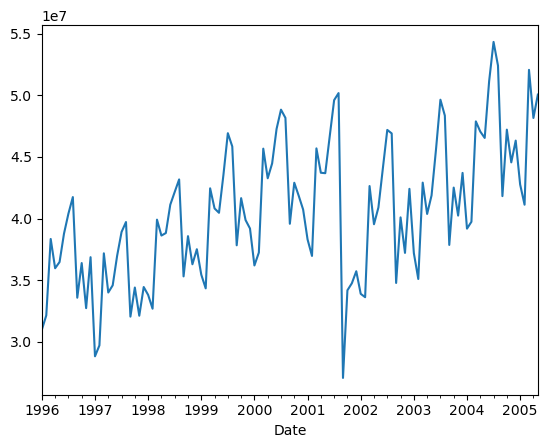

In [66]:
# Daily Closing Price Plot
df["y"].plot()
plt.show()

# Seasonality

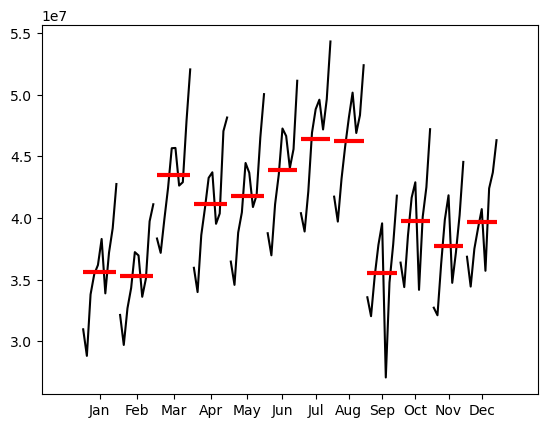

In [67]:
# Plot the month_plot
month_plot(df['y'])
plt.show()

In [ ]:
# Plot the quarter_plot
quarter_plot(df['y'])
plt.show()

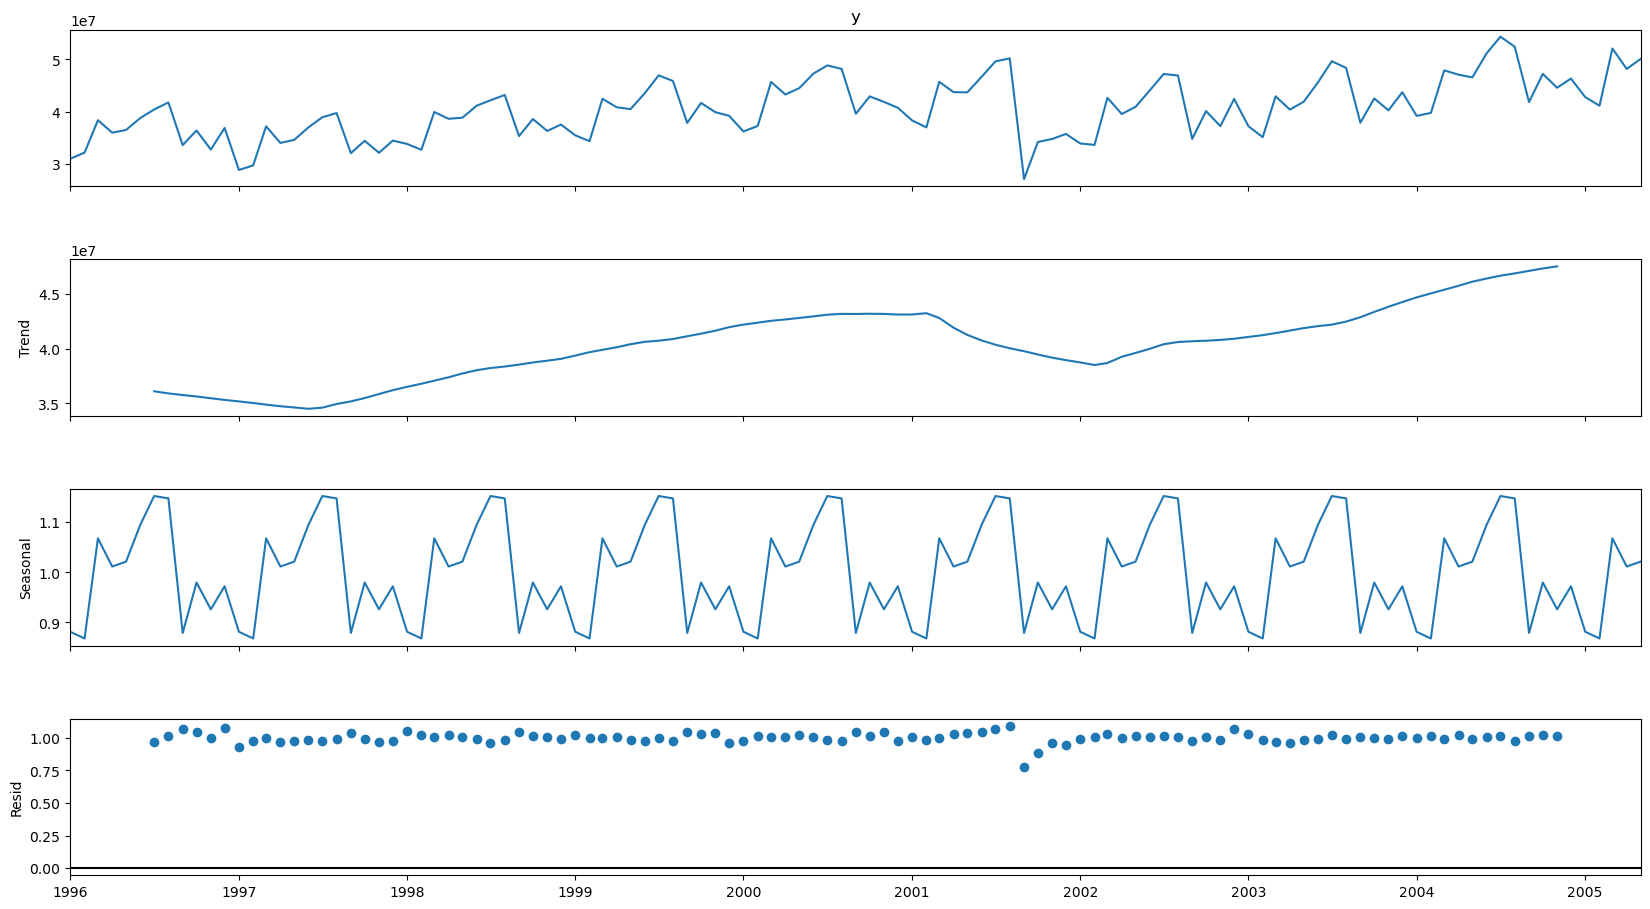

In [104]:
# Seasonal decomposition for df['Adj. Close']
decomposition = seasonal_decompose(df['y'],
                                  model = 'multiplicative',
                                  period = 12,
                                  )
fig = decomposition.plot()
fig.set_size_inches(18, 10)
plt.show()

# (Partial) Auto-Correlation

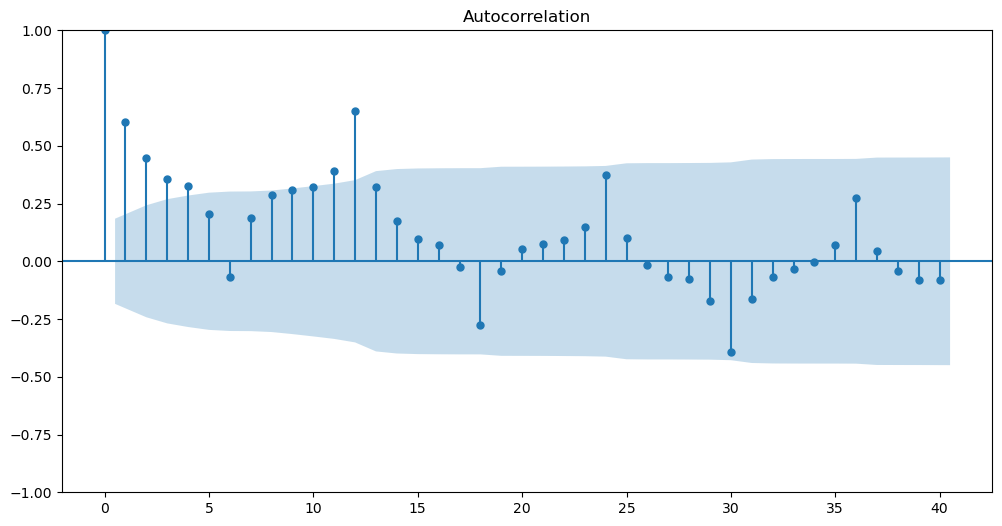

In [105]:
# Plot the ACF of the
fig, ax = plt.subplots(figsize = (12, 6))
plot_acf(df['y'], lags = 40, ax = ax)
plt.show()

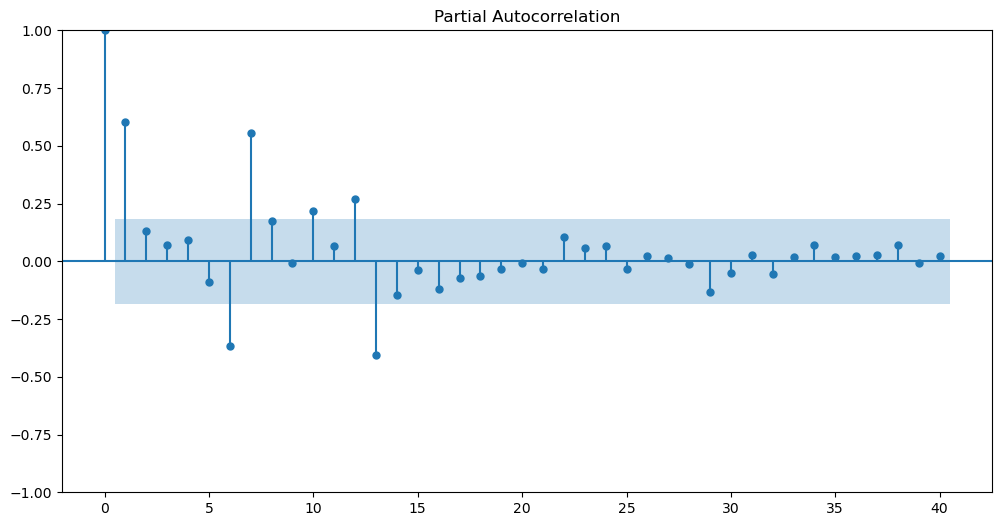

In [106]:
# PACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_pacf(df['y'], lags = 40, ax = ax)
plt.show()

## Train / Test

In [92]:
train_df , test_df = df.iloc[:-12], df.iloc[-12:]

# Model Assessment

In [107]:
model_holt = ExponentialSmoothing(train_df['y'], trend = "add", seasonal = "mul", seasonal_periods = 12).fit()
# model_holt.summary()

/home/tzvikifisher/anaconda3/envs/py312/lib/python3.13/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [111]:
holt_pred = model_holt.forecast(steps = len(test_df)).rename("Holt-Winters Forecast")
holt_pred

2004-06-01    4.985031e+07
2004-07-01    5.224279e+07
2004-08-01    5.236168e+07
2004-09-01    4.136596e+07
2004-10-01    4.618046e+07
2004-11-01    4.350886e+07
2004-12-01    4.564370e+07
2005-01-01    4.123315e+07
2005-02-01    4.082851e+07
2005-03-01    5.023941e+07
2005-04-01    4.767275e+07
2005-05-01    4.818133e+07
Freq: MS, Name: Holt-Winters Forecast, dtype: float64

In [109]:
# Function that assesses the model and visualizes the train, test and forecast
def model_assessment(train, test, predictions, chart_title = None):
  # Set the chart size
  plt.figure(figsize = (10, 4))

  # Plot the train, test and forecast
  plt.plot(train, label = "Train")
  plt.plot(test, label = "Test")
  plt.plot(predictions, label = "Forecast")
  plt.title(chart_title)
  plt.legend()
  plt.show()

  # Calculate and print the RMSE, MAE, and MAPE
  rmse = root_mean_squared_error(test, predictions)
  mae = mean_absolute_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)
  print(f"RMSE: {rmse:.0f}")
  print(f"MAE: {mae:.0f}")
  print(f"MAPE: {100 * mape:.1f} %")

In [ ]:
holt_pred

12

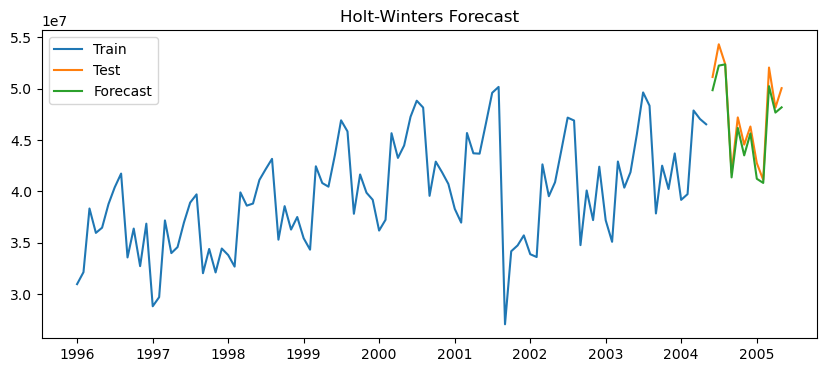

RMSE: 1230641
MAE: 1046934
MAPE: 2.2 %


In [112]:
model_assessment(train_df['y'], test_df['y'], predictions=holt_pred, chart_title = "Holt-Winters Forecast")

# Plot the future

/home/tzvikifisher/anaconda3/envs/py312/lib/python3.13/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


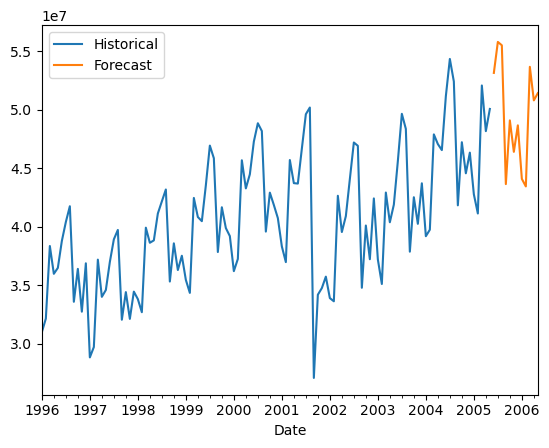

In [113]:
model_complete = ExponentialSmoothing(df['y'], trend = "add", seasonal = "mul", seasonal_periods = 12).fit()
future_pred = model_complete.forecast(steps = 12).rename("Holt-Winters Forecast")

df.y.plot(label = "Historical")
future_pred.plot(label = "Forecast")
plt.legend()
plt.show()

In [ ]:
def plot_future(y, forecast, chart_title = None):
  # Plot the training data and forecast
  plt.figure(figsize = (10, 4))

  # Plot the train, test and forecast
  plt.plot(y, label = "Train")
  plt.plot(forecast, label = "Forecast")

  # Add a title and legend to the plot
  plt.title(chart_title)
  plt.legend()
  plt.show()
